In [8]:
target_cols = 'K_Rho'
input_folder=f'C:/Users/1/projects/zadachi/3 задача/{target_cols} determ'
output_file=f'{target_cols} determ.csv'

columns = ['K_Nu', 'K_E', 'K_Rho', 'K_incl', 'F', 'K_lambda_r', 'A2', 'А2_surface',  'Nu_host medium', 'E', 'Rho', 'Vp', 'Vs', 'Z']

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
df = pd.read_csv(output_file)

# Подготовка данных
df['A2/A2_s'] = df['A2'] / df['А2_surface']
y = df[target_cols]
X = df[['A2/A2_s', 'F']]


In [10]:
df

,K_Nu,K_E,K_Rho,K_incl_top_position_y,F,K_lambda_r,A2,А2_surface,Nu_host medium,E,Rho,Vp,Vs,Z,A2/A2_s
0,1,1,0.5000,1,0.1,10.000000,5.331446e-13,5.331538e-13,0.25,5.000000e+10,2700,6666.666667,3849.001795,2502.294446,0.999983
1,1,1,0.5000,1,0.2,5.000000,5.334684e-13,5.331396e-13,0.25,5.000000e+10,2700,6666.666667,3849.001795,2502.294446,1.000617
2,1,1,0.5000,1,0.3,3.333333,5.366619e-13,5.363270e-13,0.25,5.000000e+10,2700,6666.666667,3849.001795,2502.294446,1.000624
3,1,1,0.5000,1,0.4,2.500000,5.329808e-13,5.332607e-13,0.25,5.000000e+10,2700,6666.666667,3849.001795,2502.294446,0.999475
4,1,1,0.5000,1,0.5,2.000000,5.337385e-13,5.340060e-13,0.25,5.000000e+10,2700,6666.666667,3849.001795,2502.294446,0.999499
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100095,1,1,0.5135,1,9.6,0.104167,4.945343e-13,5.119005e-13,0.25,5.000000e+10,2700,6578.449106,3798.069362,2502.294446,0.966075
100096,1,1,0.5135,1,9.7,0.103093,4.943165e-13,5.115627e-13,0.25,5.000000e+10,2700,6578.449106,3798.069362,2502.294446,0.966287
100097,1,1,0.5135,1,9.8,0.102041,4.941462e-13,5.112649e-13,0.25,5.000000e+10,2700,6578.449106,3798.069362,2502.294446,0.966517
100098,1,1,0.5135,1,9.9,0.101010,4.940200e-13,5.110043e-13,0.25,5.000000e+10,2700,6578.449106,3798.069362,2502.294446,0.966763


In [11]:
def create_and_train_model(X_train, y_train, X_test, y_test, sample_size):
    """Создает и обучает модель на данных заданного размера"""
    
    scaler_X = StandardScaler()
    
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)
    
    # Создание модели
    model = Sequential([
        Dense(128, activation='relu', input_shape=(2,), name='hidden_layer_1'),
        Dropout(0.2),  # Добавляем Dropout для регуляризации
        Dense(64, activation='relu', name='hidden_layer_2'),
        Dropout(0.2),
        Dense(1, name='output_layer')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    
    # Ранняя остановка
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True
    )
    
    # Обучение
    history = model.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=min(32, len(X_train)//10),
        callbacks=[early_stopping],
        verbose=0
    )
    
    # Предсказание
    y_pred = np.array(model.predict(X_test_scaled)).flatten()
    y_test = np.array(y_test)
    
    # Метрики
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    # Относительная ошибка
    relative_errors = np.abs((y_test - y_pred) / y_test) * 100
    mean_relative_error = np.mean(relative_errors)
    std_relative_error = np.std(relative_errors)
    
    return {
        'sample_size': sample_size,
        'mse': mse,
        'mae': mae,
        'mape': mape,
        'rmse': rmse,
        'r2': r2,
        'mean_rel_error': mean_relative_error,
        'std_rel_error': std_relative_error,
        'accuracy': 100 - mean_relative_error,
        'history': history.history
    }

# Основной анализ
print("="*70)
print("АНАЛИЗ ВЛИЯНИЯ КОЛИЧЕСТВА ДАННЫХ НА КАЧЕСТВО ПРЕДСКАЗАНИЯ K_E")
print("="*70)

# Размеры выборок для анализа
sample_sizes = [100, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000, 100000]
n_repetitions = 3  # Количество повторений для каждого размера (для усреднения)

results = []

# Фиксируем тестовую выборку (20% от всех данных)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

АНАЛИЗ ВЛИЯНИЯ КОЛИЧЕСТВА ДАННЫХ НА КАЧЕСТВО ПРЕДСКАЗАНИЯ K_E


In [ ]:

print(f"\nТестовая выборка фиксирована: {len(X_test)} образцов")
print(f"Обучающая выборка (полная): {len(X_train_full)} образцов")
print("\n" + "-"*70)

for size in sample_sizes:
    print(f"\nАнализ для размера выборки: {size}")
    
    size_results = []
    
    for rep in range(n_repetitions):
        # Случайно выбираем size образцов из обучающей выборки
        indices = np.random.choice(len(X_train_full), size=min(size, len(X_train_full)), replace=False)
        X_train_sample = X_train_full.iloc[indices]
        y_train_sample = y_train_full.iloc[indices]
        
        # Обучаем и оцениваем модель
        result = create_and_train_model(
            X_train_sample, y_train_sample,
            X_test, y_test,
            size
        )
        size_results.append(result)
        
        print(f"  Повторение {rep+1}/{n_repetitions}: "
              f"Точность = {result['accuracy']:.2f}%")
    
    # Усредняем результаты по повторениям
    avg_result = {
        'sample_size': size,
        'mse': np.mean([r['mse'] for r in size_results]),
        'mae': np.mean([r['mae'] for r in size_results]),
        'mape': np.mean([r['mape'] for r in size_results]),
        'rmse': np.mean([r['rmse'] for r in size_results]),
        'r2': np.mean([r['r2'] for r in size_results]),
        'mean_rel_error': np.mean([r['mean_rel_error'] for r in size_results]),
        'std_rel_error': np.mean([r['std_rel_error'] for r in size_results]),
        'accuracy': np.mean([r['accuracy'] for r in size_results]),
        'accuracy_std': np.std([r['accuracy'] for r in size_results])
    }
    
    results.append(avg_result)
    
    print(f"\n  СРЕДНЕЕ для размера {size}:")
    print(f"    Точность: {avg_result['accuracy']:.2f}% ± {avg_result['accuracy_std']:.2f}%")
    print(f"    R²: {avg_result['r2']:.4f}")
    print(f"    RMSE: {avg_result['rmse']:.6f}")
    print(f"    MAE: {avg_result['mae']:.6f}")
    print(f"    MAPE: {avg_result['mape']:.6f}")

# Создаем DataFrame с результатами
results_df = pd.DataFrame(results)
results_df.to_csv(f'{target_cols} size result.csv', index=False)
print('Датасет сохранен')


Тестовая выборка фиксирована: 20020 образцов
Обучающая выборка (полная): 80080 образцов

----------------------------------------------------------------------

Анализ для размера выборки: 100
626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
  Повторение 1/3: Точность = 79.66%
626/626 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
  Повторение 2/3: Точность = 81.26%
626/626 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
  Повторение 3/3: Точность = 76.98%

  СРЕДНЕЕ для размера 100:
    Точность: 79.30% ± 1.77%
    R²: 0.5516
    RMSE: 0.289779
    MAE: 0.214680
    MAPE: 0.206994

Анализ для размера выборки: 200
626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
  Повторение 1/3: Точность = 84.19%
626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
  Повторение 2/3: Точность = 82.86%
626/626 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step
  Повторение 3/3: Точность = 82.19%

  СРЕДНЕЕ для размера 200:
    Точность: 83.08% ± 0.83%
    R²: 0.6346
    RMSE: 0.261628
    MAE: 0.181496
    MAPE: 0.169181

Анализ для размера выборки: 500
626/626 ━━━━━━━━━━━━━

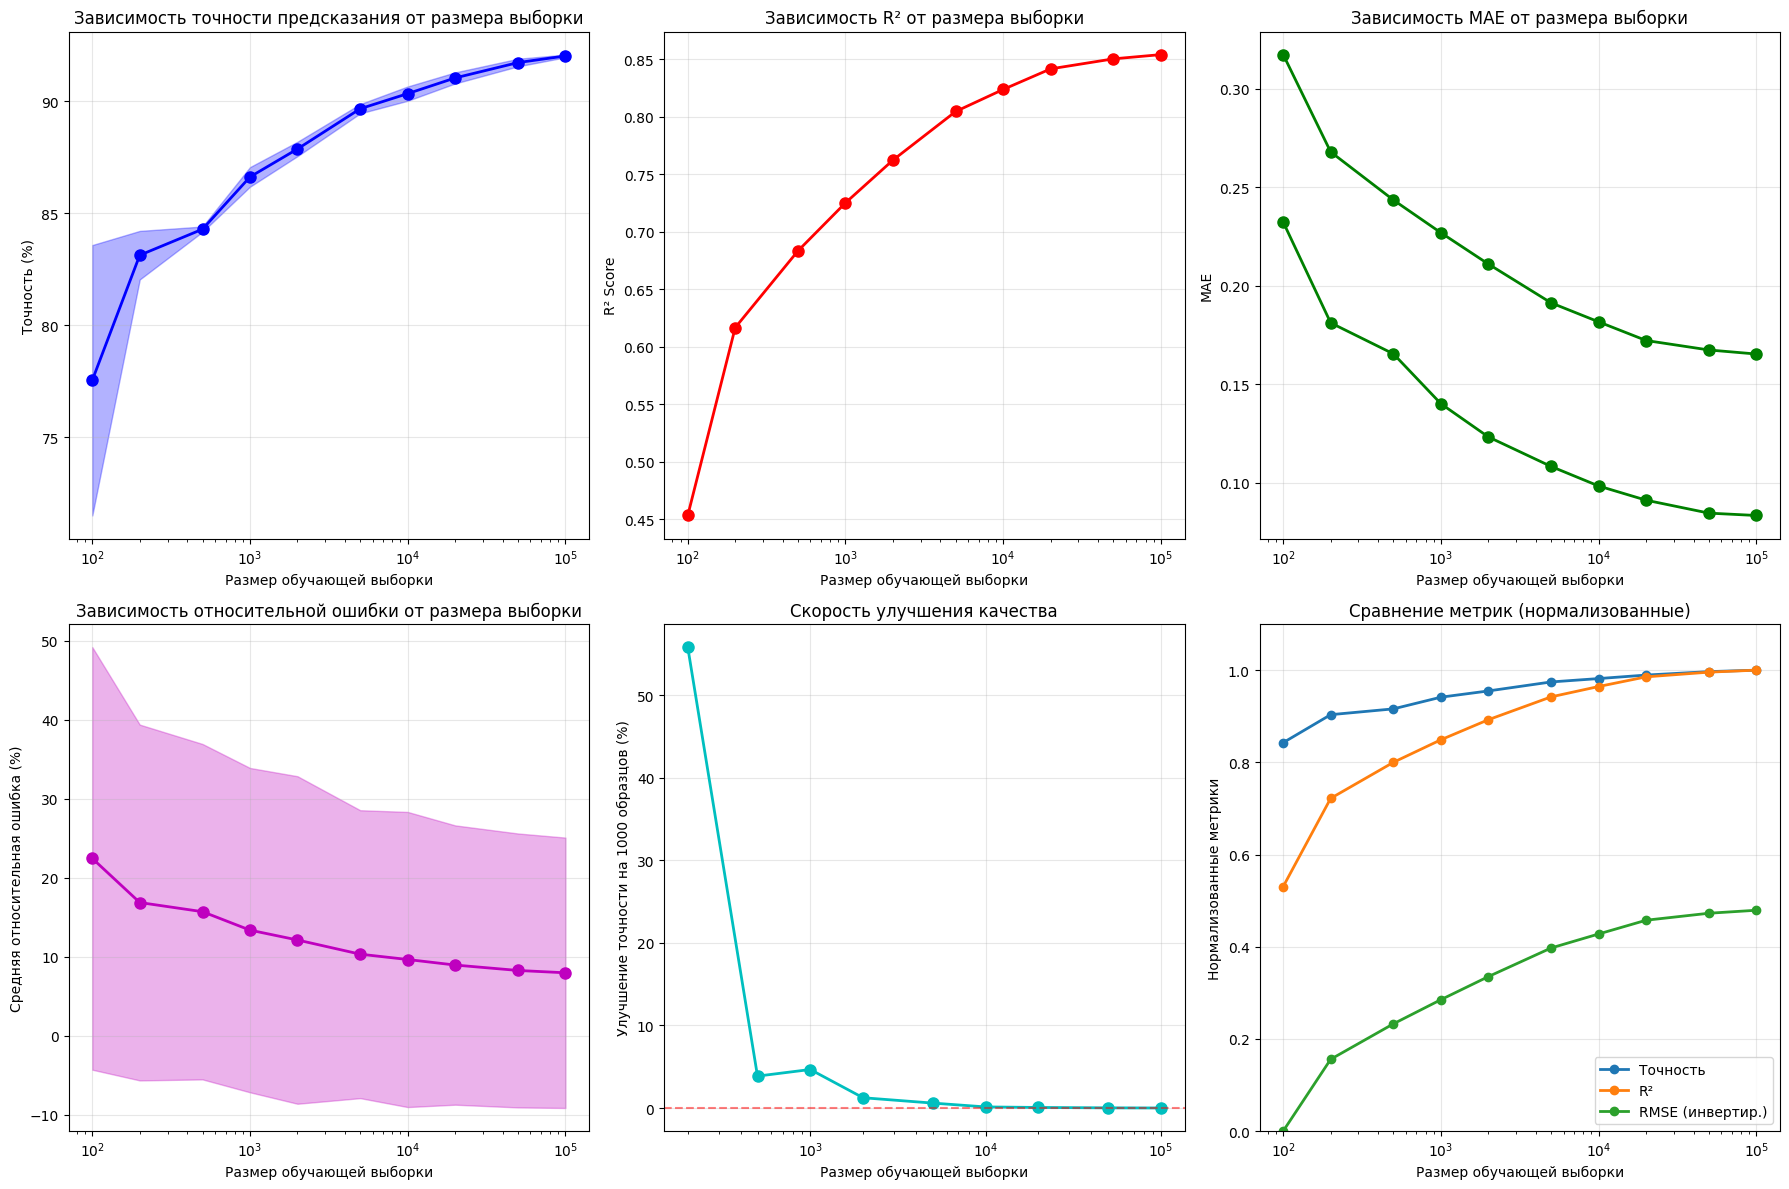

In [ ]:

# Визуализация результатов
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Точность предсказания от размера выборки
axes[0, 0].plot(results_df['sample_size'], results_df['accuracy'], 'bo-', linewidth=2, markersize=8)
axes[0, 0].fill_between(results_df['sample_size'], 
                        results_df['accuracy'] - results_df['accuracy_std'],
                        results_df['accuracy'] + results_df['accuracy_std'],
                        alpha=0.3, color='b')
axes[0, 0].set_xlabel('Размер обучающей выборки')
axes[0, 0].set_ylabel('Точность (%)')
axes[0, 0].set_title('Зависимость точности предсказания от размера выборки')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xscale('log')

# 2. R² от размера выборки
axes[0, 1].plot(results_df['sample_size'], results_df['r2'], 'ro-', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Размер обучающей выборки')
axes[0, 1].set_ylabel('R² Score')
axes[0, 1].set_title('Зависимость R² от размера выборки')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xscale('log')

# 3. RMSE от размера выборки
axes[0, 2].plot(results_df['sample_size'], results_df['rmse'], 'go-', linewidth=2, markersize=8)
axes[0, 2].set_xlabel('Размер обучающей выборки')
axes[0, 2].set_ylabel('RMSE')
axes[0, 2].set_title('Зависимость RMSE от размера выборки')
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].set_xscale('log')

# 3.2 MAE от размера выборки
axes[0, 2].plot(results_df['sample_size'], results_df['mae'], 'go-', linewidth=2, markersize=8)
axes[0, 2].set_xlabel('Размер обучающей выборки')
axes[0, 2].set_ylabel('MAE')
axes[0, 2].set_title('Зависимость MAE от размера выборки')
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].set_xscale('log')

# 4. Относительная ошибка от размера выборки
axes[1, 0].plot(results_df['sample_size'], results_df['mean_rel_error'], 'mo-', linewidth=2, markersize=8)
axes[1, 0].fill_between(results_df['sample_size'],
                        results_df['mean_rel_error'] - results_df['std_rel_error'],
                        results_df['mean_rel_error'] + results_df['std_rel_error'],
                        alpha=0.3, color='m')
axes[1, 0].set_xlabel('Размер обучающей выборки')
axes[1, 0].set_ylabel(' MAPE (%)')
axes[1, 0].set_title('Зависимость MAPE от размера выборки')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xscale('log')

# 5. Скорость обучения (время/качество)
improvement = []
for i in range(1, len(results_df)):
    imp = (results_df['accuracy'].iloc[i] - results_df['accuracy'].iloc[i-1]) / \
          (results_df['sample_size'].iloc[i] - results_df['sample_size'].iloc[i-1])
    improvement.append(imp * 1000)  # Умножаем для лучшей визуализации

axes[1, 1].plot(results_df['sample_size'].iloc[1:], improvement, 'co-', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('Размер обучающей выборки')
axes[1, 1].set_ylabel('Улучшение точности на 1000 образцов (%)')
axes[1, 1].set_title('Скорость улучшения качества')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xscale('log')
axes[1, 1].axhline(y=0, color='r', linestyle='--', alpha=0.5)

# 6. Сравнение метрик (нормализованные)
metrics_normalized = pd.DataFrame({
    'Точность': results_df['accuracy'] / results_df['accuracy'].max(),
    'R²': results_df['r2'] / results_df['r2'].max(),
    'RMSE (инвертир.)': 1 - results_df['rmse'] / results_df['rmse'].max()
})

for metric in metrics_normalized.columns:
    axes[1, 2].plot(results_df['sample_size'], metrics_normalized[metric], 
                   'o-', linewidth=2, markersize=6, label=metric)

axes[1, 2].set_xlabel('Размер обучающей выборки')
axes[1, 2].set_ylabel('Нормализованные метрики')
axes[1, 2].set_title('Сравнение метрик (нормализованные)')
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].set_xscale('log')
axes[1, 2].legend()
axes[1, 2].set_ylim([0, 1.1])

plt.tight_layout()
plt.show()


In [ ]:
results_df

,sample_size,mse,mae,mape,rmse,r2,mean_rel_error,std_rel_error,accuracy,accuracy_std
0,100,0.102490,0.232385,0.224470,0.317459,0.453073,22.446999,26.729154,77.553001,6.032363
1,200,0.071860,0.181216,0.168660,0.268030,0.616526,16.866021,22.504163,83.133979,1.082998
2,500,0.059346,0.165462,0.157065,0.243595,0.683304,15.706503,21.215559,84.293497,0.118940
3,1000,0.051522,0.140128,0.133738,0.226975,0.725060,13.373765,20.515460,86.626235,0.436878
4,2000,0.044554,0.123266,0.121269,0.211073,0.762240,12.126900,20.716703,87.873100,0.320961
5,5000,0.036623,0.108266,0.103313,0.191361,0.804565,10.331252,18.211315,89.668748,0.208044
6,10000,0.033032,0.098359,0.096577,0.181730,0.823728,9.657716,18.666809,90.342284,0.318408
7,20000,0.029675,0.091145,0.089571,0.172251,0.841644,8.957065,17.666352,91.042935,0.246876
8,50000,0.028043,0.084575,0.082728,0.167444,0.850354,8.272806,17.327439,91.727194,0.170059
9,100000,0.027351,0.083377,0.079774,0.165380,0.854044,7.977375,17.102311,92.022625,0.060247
